Libraries:

In [5]:
import API_fetcher as API
import pandas as pd
import duckdb as db

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
db.sql("""
       SELECT *
       FROM read_parquet('crimes_clean_dedup_all_years.parquet') as crimes
       LIMIT 1 
       """).df().info()
       

<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Month         1 non-null      str  
 1   Falls within  1 non-null      str  
 2   Longitude     1 non-null      str  
 3   Latitude      1 non-null      str  
 4   LSOA code     1 non-null      str  
 5   LSOA name     1 non-null      str  
 6   Crime type    1 non-null      str  
dtypes: str(7)
memory usage: 273.0 bytes


In [11]:
db.sql("""
SELECT min(Month)
FROM read_parquet('crimes_clean_dedup_all_years.parquet') as crimes
""").df()

,"min(""Month"")"
0,2010-12


In [7]:
db.sql("""
SELECT max(Month)
FROM read_parquet('crimes_clean_dedup_all_years.parquet') as crimes
""").df()

,"max(""Month"")"
0,2026-03


In [3]:

# Get total crimes per LSOA from parquet
lsoa_counts = db.sql("""
    SELECT 
        "LSOA code" AS lsoa_code,
        COUNT(*) AS total_crimes
    FROM read_parquet('crimes_clean_dedup_all_years.parquet') AS crimes
    WHERE "LSOA code" IS NOT NULL
    GROUP BY "LSOA code"
""").df()
lsoa_counts.head()

,lsoa_code,total_crimes
0,E01013580,982
1,E01020020,1977
2,E01020109,826
3,E01015975,1639
4,E01004914,333


In [7]:
#Number of LSOAs
lsoa_counts.shape[0]

36747

In [10]:
lsoa_counts["percentage_of_total"] = (lsoa_counts["total_crimes"] / lsoa_counts["total_crimes"].sum()) * 100
lsoa_counts.sort_values(by="percentage_of_total", ascending=False, inplace=True)
lsoa_counts.head()

,lsoa_code,total_crimes,percentage_of_total
36269,E01032739,54174,0.084623
32301,E01033010,44482,0.069483
28219,E01004734,40398,0.063104
18663,E01033595,38235,0.059725
14082,E01004763,34889,0.054499


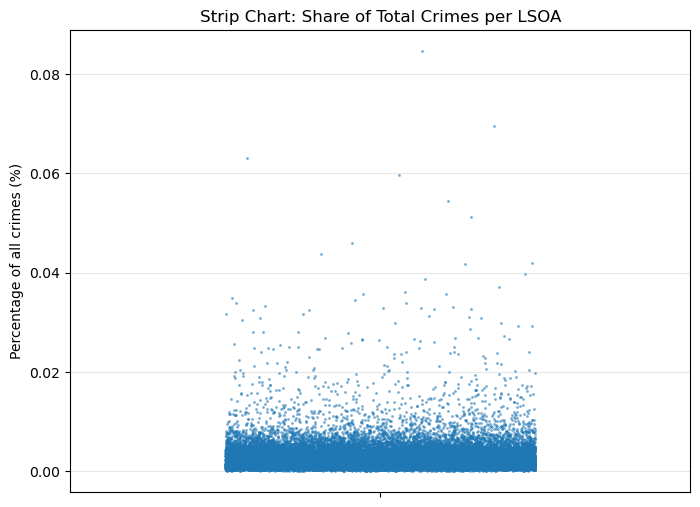

In [13]:
plt.figure(figsize=(8, 6))

sns.stripplot(
    data=lsoa_counts,
    y="percentage_of_total",
    jitter=0.25,
    alpha=0.60,
    size=2
)

plt.ylabel("Percentage of all crimes (%)")
plt.title("Strip Chart: Share of Total Crimes per LSOA")
plt.grid(axis="y", alpha=0.3)


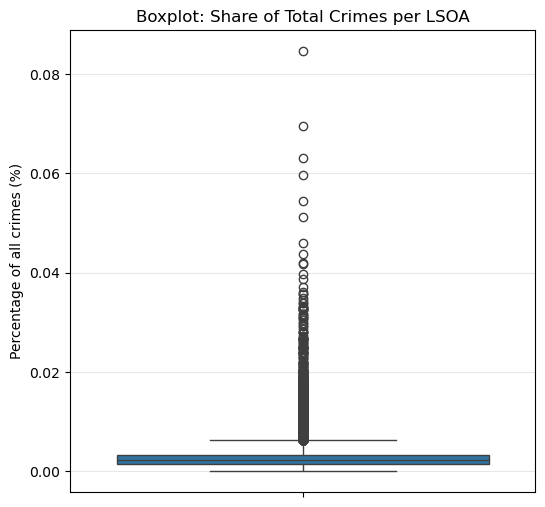

In [14]:
plt.figure(figsize=(6, 6))

sns.boxplot(
    data=lsoa_counts,
    y="percentage_of_total"
)

plt.ylabel("Percentage of all crimes (%)")
plt.title("Boxplot: Share of Total Crimes per LSOA")
plt.grid(axis="y", alpha=0.3)


In [21]:
lsoa_counts["percentage_of_total"].max() #0.0846227839511939
lsoa_counts[lsoa_counts["percentage_of_total"] == lsoa_counts["percentage_of_total"].max()]

,lsoa_code,total_crimes,percentage_of_total
36269,E01032739,54174,0.084623


In [22]:
db.sql("""SELECT * 
       FROM read_parquet('crimes_clean_dedup_all_years.parquet') AS crimes
         WHERE "LSOA code" = 'E01032739'
         """).df()

,Month,Falls within,Longitude,Latitude,LSOA code,LSOA name,Crime type
0,2013-05,Metropolitan Police Service,-0.082913,51.513463,E01032739,City of London 001F,Other theft
1,2013-06,City of London Police,-0.084723,51.514986,E01032739,City of London 001F,Theft from the person
2,2013-06,City of London Police,-0.088225,51.514656,E01032739,City of London 001F,Other crime
3,2013-07,City of London Police,-0.078924,51.508587,E01032739,City of London 001F,Anti-social behaviour
4,2013-07,City of London Police,-0.078856,51.518433,E01032739,City of London 001F,Other theft
...,...,...,...,...,...,...,...
54169,2026-02,City of London Police,-0.084754,51.512882,E01032739,City of London 001F,Other theft
54170,2026-02,City of London Police,-0.079127,51.509607,E01032739,City of London 001F,Public order
54171,2026-02,City of London Police,-0.089208,51.509744,E01032739,City of London 001F,Theft from the person
54172,2026-02,City of London Police,-0.102272,51.511656,E01032739,City of London 001F,Theft from the person


### CRIME TYPES

In [26]:
db.sql("""
SELECT 
    "Crime type",
    COUNT(*) AS n,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM read_parquet('crimes_clean_dedup_all_years.parquet')
GROUP BY "Crime type"
ORDER BY pct DESC
""").df()

,Crime type,n,pct
0,Anti-social behaviour,15849458,24.10
1,Violence and sexual offences,13761889,20.92
2,Criminal damage and arson,6341518,9.64
3,Other theft,5412595,8.23
4,Vehicle crime,5023592,7.64
5,Burglary,4813996,7.32
6,Public order,3808343,5.79
7,Other crime,2162898,3.29
8,Shoplifting,2056432,3.13
9,Drugs,2045619,3.11


In [30]:
#London Crime Category Distribution for City of London Police
db.sql("""
SELECT 
    "Falls within",
    COUNT(*) AS n,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM read_parquet('crimes_clean_dedup_all_years.parquet')
GROUP BY "Falls within"
ORDER BY pct DESC
""").df()

,Falls within,n,pct
0,Metropolitan Police Service,10779828,16.39
1,West Midlands Police,3297254,5.01
2,West Yorkshire Police,3285282,4.99
3,Greater Manchester Police,2207014,3.36
4,Thames Valley Police,2019439,3.07
5,Lancashire Constabulary,2006474,3.05
6,Kent Police,1981429,3.01
7,Hampshire Constabulary,1960071,2.98
8,South Yorkshire Police,1904405,2.90
9,Essex Police,1898888,2.89


In [37]:
#London Crime Category Distribution for metropolitan Police Service
db.sql("""
SELECT 
    "Crime type",
    COUNT(*) AS n,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM read_parquet('crimes_clean_dedup_all_years.parquet')
WHERE "Falls within" = 'Metropolitan Police Service'
GROUP BY "Crime type"
ORDER BY pct DESC
""").df()

,Crime type,n,pct
0,Anti-social behaviour,2109191,19.57
1,Violence and sexual offences,1863716,17.29
2,Vehicle crime,1255626,11.65
3,Other theft,1064664,9.88
4,Burglary,912445,8.46
5,Criminal damage and arson,704935,6.54
6,Public order,506938,4.70
7,Drugs,470659,4.37
8,Theft from the person,382465,3.55
9,Robbery,373691,3.47


In [38]:
force_crime_type_counts = db.sql("""
SELECT 
    "Falls within" AS police_force,
    "Crime type" AS crime_type,
    COUNT(*) AS total_crimes
FROM read_parquet('crimes_clean_dedup_all_years.parquet')
GROUP BY "Falls within", "Crime type"
ORDER BY police_force, total_crimes DESC
""").df()

force_crime_type_counts

,police_force,crime_type,total_crimes
0,Avon and Somerset Constabulary,Anti-social behaviour,394315
1,Avon and Somerset Constabulary,Violence and sexual offences,383447
2,Avon and Somerset Constabulary,Criminal damage and arson,166168
3,Avon and Somerset Constabulary,Public order,145329
4,Avon and Somerset Constabulary,Other theft,139411
...,...,...,...
715,Wiltshire Police,Bicycle theft,8050
716,Wiltshire Police,Possession of weapons,4009
717,Wiltshire Police,Theft from the person,3849
718,Wiltshire Police,Robbery,3489
